## Problem Statement
> Develop a binary classification model that predicts whether an observation belongs to the diabetic or non-diabetic class based on the available clinical features.

## Dataset
The dataset used is the Pima Indian Diabetes Database from Kaggle. The link is https://www.kaggle.com/datasets/mragpavank/diabetes

## Evaluation
> Primary evaluation metric: Recall. The goal is to minimize false negatives because failing to identify a patient who may have diabetes is considered more costly than generating a false positive. A target recall of 90% will be investigated, while also monitoring precision and other relevant metrics.

## Features
1. Pregnancies: Number of times pregnant.
2. Glucose: Plasma glucose concentration from a oral glucose tolerance test.
3. Blood Pressure: Diastolic blood pressure (mm Hg).
4. Skin Thickness: Triceps skin fold thickness (mm).
5. Insulin: 2-Hour serum insulin (μU/ml).
6. BMI: Body mass index (weight in kg/(height in m)²).
7. Diabetes Pedigree Function: Score providing information on diabetes history in relatives.
8. Age: Age in years.
9. Outcome (0 for non-diabetic, 1 for diabetic)

## Load Dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('../data/diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
# Check the shape of the data
df.shape

(768, 9)

There are 768 sample in the dataset with 8 predictors

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


There are no missing values in the dataset

In [6]:
# Check for duplicates
df.duplicated().sum()

np.int64(0)

There are no duplicates in the dataset

In [7]:
# Let's look at statistical summary
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


Some zero values are likely representing missing measurements rather than genuine physiological measurements. The zero values in the `Glucose`, `Blood Pressure`, `Skin Thickness`, `Insulin` and `BMI` columns will be investigated.

In [8]:
# View the total number of 0 values in each column
(df==0).sum()

Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64

In [9]:
# View the average percentage of 0 values in each column
(df == 0).mean() * 100

Pregnancies                 14.453125
Glucose                      0.651042
BloodPressure                4.557292
SkinThickness               29.557292
Insulin                     48.697917
BMI                          1.432292
DiabetesPedigreeFunction     0.000000
Age                          0.000000
Outcome                     65.104167
dtype: float64

Almost half of the data has 0 `Insulin` value

In [10]:
for col in ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']:
    print((df.groupby('Outcome')[col].apply(lambda x: (x == 0).sum())))

Outcome
0    3
1    2
Name: Glucose, dtype: int64
Outcome
0    19
1    16
Name: BloodPressure, dtype: int64
Outcome
0    139
1     88
Name: SkinThickness, dtype: int64
Outcome
0    236
1    138
Name: Insulin, dtype: int64
Outcome
0    9
1    2
Name: BMI, dtype: int64


In [11]:
df.groupby('Outcome')['Insulin'].apply(lambda x: (x == 0).mean() * 100)

Outcome
0    47.200000
1    51.492537
Name: Insulin, dtype: float64

51% of the Diabetic group (Outcome 1) has zero values while 47% of the Non-diabetic (Outcome 0) group has zero values

## Exploratory Data Analysis

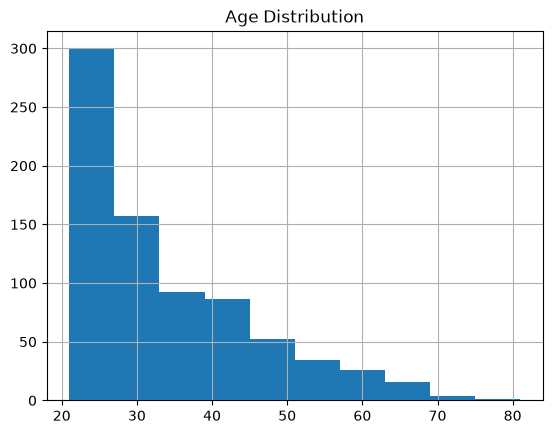

In [12]:
# Age Distribution
df['Age'].hist()
plt.title('Age Distribution');

The age distribution is positively skewed, with most patients concentrated in the younger age groups, particularly between approximately 21 and 30 years. The frequency of patients decreases as age increases, resulting in a long right tail extending to approximately 80 years. This indicates that the dataset contains substantially more younger patients than older patients.

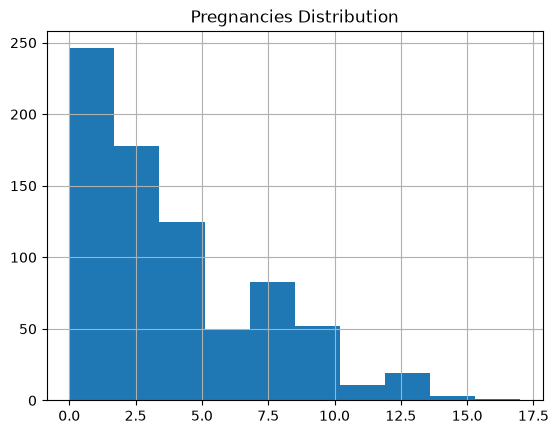

In [13]:
# Pregnancies Distribution
df['Pregnancies'].hist()
plt.title('Pregnancies Distribution');

The distribution is positively skewed, with observations concentrated at lower pregnancy counts, particularly between approximately 0 and 3 pregnancies.

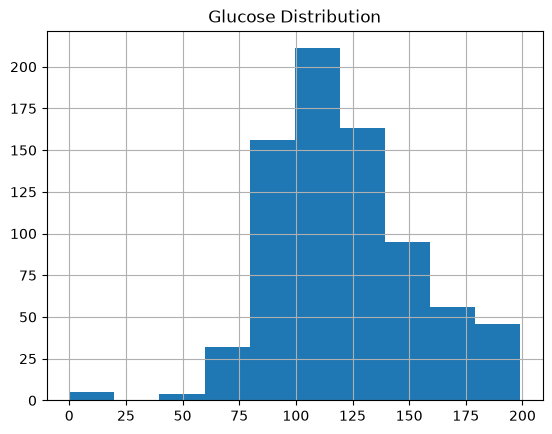

In [14]:
def histo(c):
    df[c].hist()
    plt.title(f'{c} Distribution');

histo('Glucose')

Glucose values are concentrated primarily in the middle of the observed range, while a small number of zero values appear separated from the main distribution and may represent invalid or missing measurements.

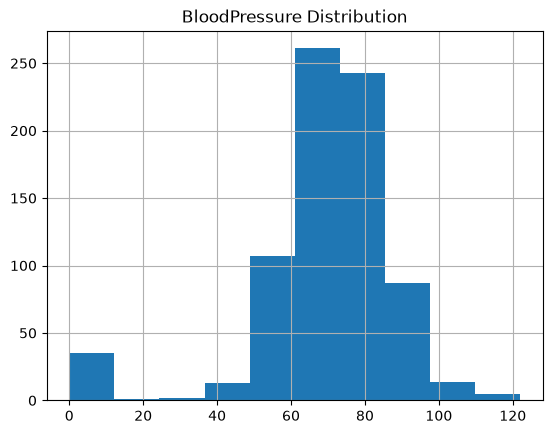

In [15]:
histo('BloodPressure')

The distribution of blood pressure is concentrated in the middle with readings between approximately 61 to 85. The outlier is 0 which is detached from the distribution. This may suggests a wrong or missing value.

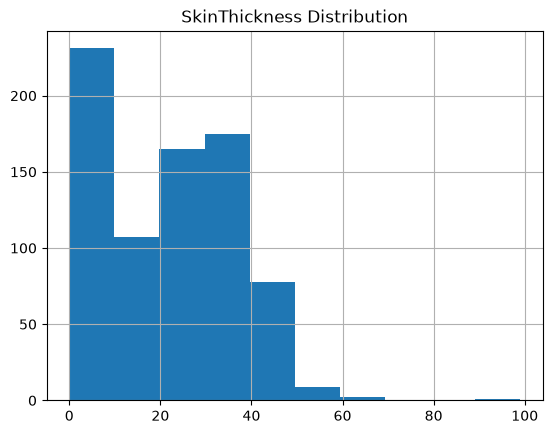

In [16]:
histo('SkinThickness')

The distribution is positively skewed but with two peaks. Most Skin Thickness is between 0 and 10. The second peak is between 20 and 40.

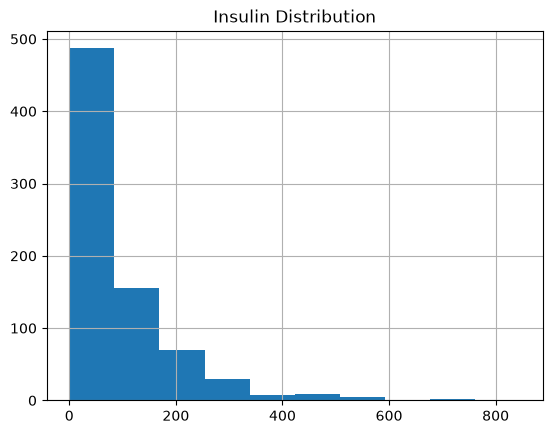

In [17]:
histo('Insulin')

The distribution is highly positively skewed with most readings being approximately between 0 and 100.

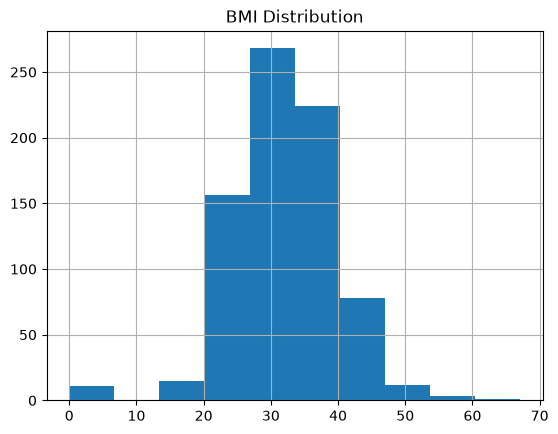

In [18]:
histo('BMI')

The distribution of BMI is concentrated in the middle with readings between approximately 20 to 40. The outlier is 0 which is detached from the distribution. This may suggests a wrong or missing value.

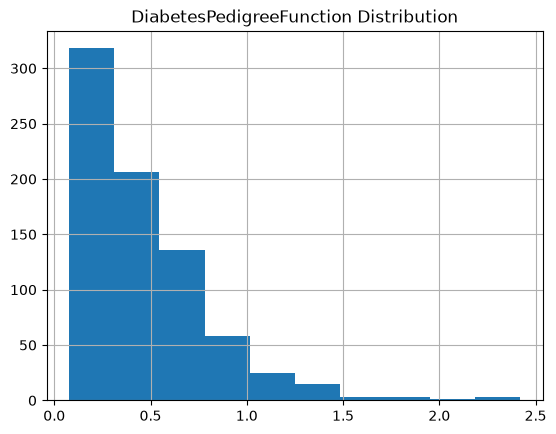

In [19]:
histo('DiabetesPedigreeFunction')

The distribution is positively skewed with most values between 0.1 to 0.5. This suggests the dataset contains more samples with lower Diabetes Pedigree Function than higher.

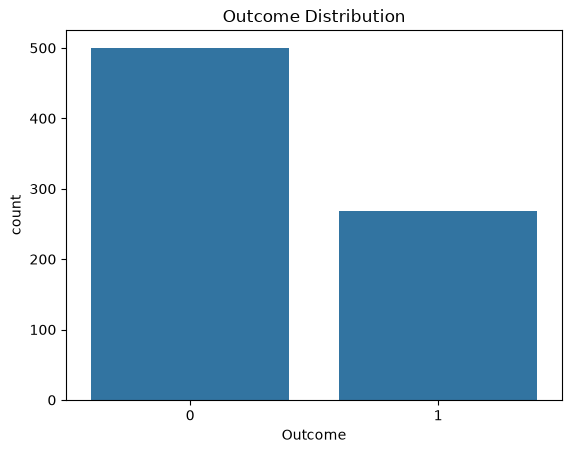

In [20]:
# Let's check the distribution of the target variable
sns.countplot(data=df, x='Outcome')
plt.title('Outcome Distribution');

In [21]:
df['Outcome'].value_counts(normalize=True) * 100

Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64

Outcome 0 represents approximately 65.1% of observations, while Outcome 1 represents approximately 34.9%, indicating moderate class imbalance.

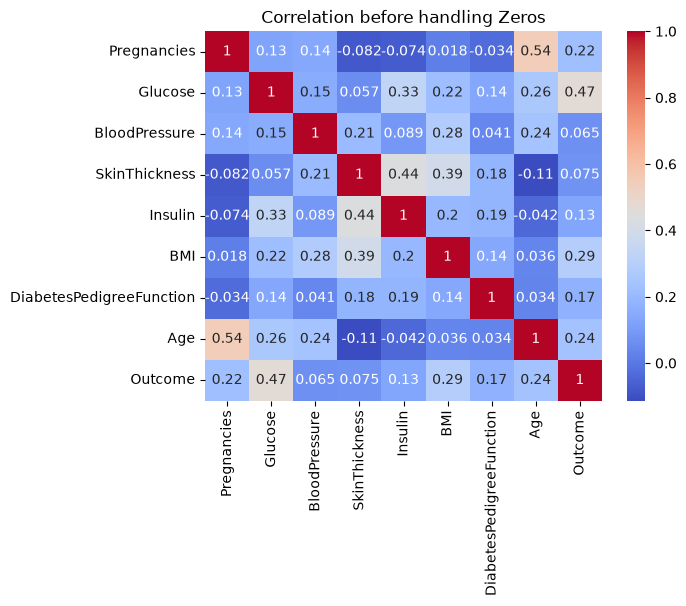

In [22]:
# Let's Check for correlation
correlation = df.corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Correlation before handling Zeros');

* There is a moderate positive correlation between `Age` and `Pregnancies`. 
* The `Outcome` is also moderately correlated with `Glucose` postively.
* The is a moderate positive correlation between `SkinThickness` and `Insulin`.
* The is a moderate positive correlation between `SkinThickness` and `BMI`.

In [23]:
data2 = df.copy()

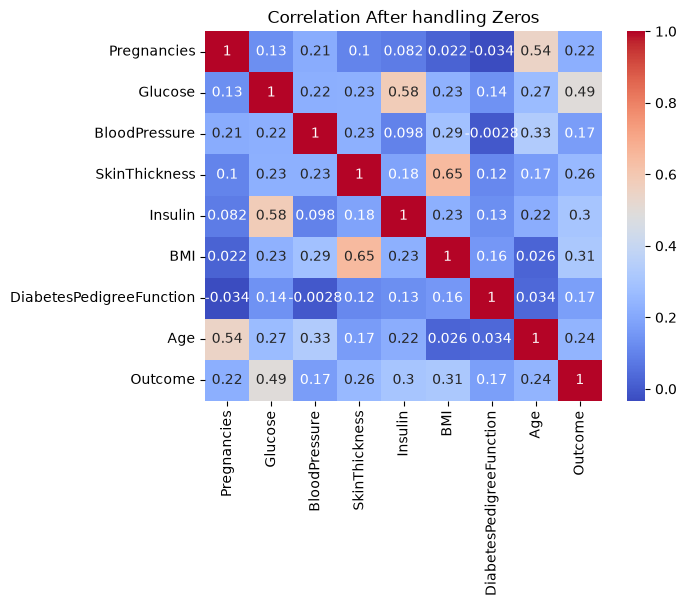

In [24]:
for col in ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']:
    data2[col] = data2[col].replace(0, np.nan)
correlation = data2.corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Correlation After handling Zeros');

* `Insulin` now has a high correlation with `Glucose`
* The correlation between `SkinThickness` and `BMI` is much higher now

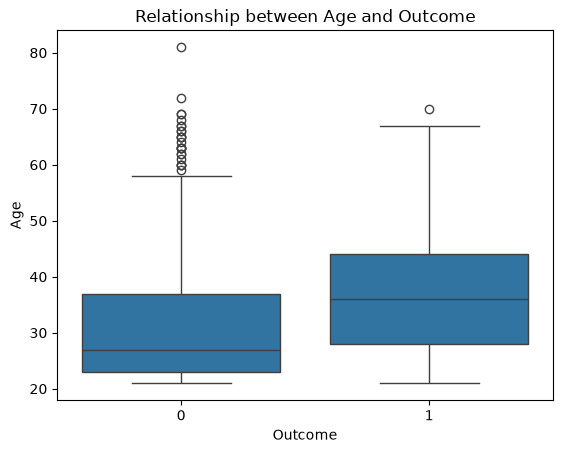

In [25]:
# Let's look at the relationship between Age and Outcome
sns.boxplot(x=df.Outcome, y=df.Age)
plt.title('Relationship between Age and Outcome');

* The middle 50% of Outcome 1 observations lie approximately between ages 29 and 44, with a median of approximately 37. There is an outlier that is 70
* The middle 50% of Outcome 0 observations lie approximately between ages 23 and 38, with a median of approximately 28. Though there are several old age outliers, they may represent legitimate observations rather than errors.
* Therefore patients with diabetes tend to be older than patients without diabetes.
* Overall, the dustribution suggests that age may be associated with diabetes status, although there is substantial overlap between the two groups.

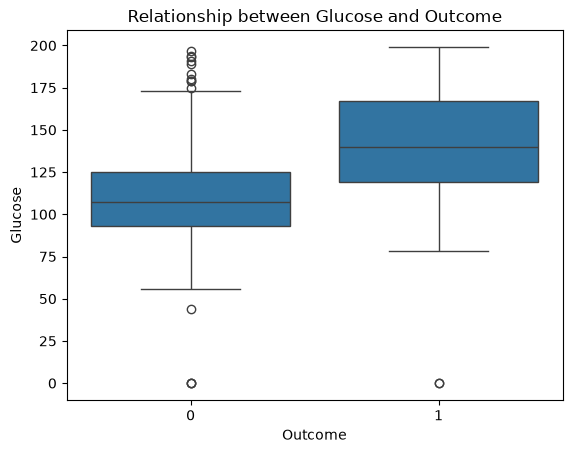

In [26]:
# Let's look at the relationship between Glucose and Outcome
sns.boxplot(x=df.Outcome, y=df.Glucose)
plt.title('Relationship between Glucose and Outcome');

Patients with diabetes (Outcome 1) tend to have a much higher glucose level of approximately 140 when compared to 110 of non-diabetes (Outcome 0). 
50% of patients with diabetes fall within the range of approximately 120 to 170 while for non-diabetes it is approximately 90 to 125.
There are some outliers in the non-diabetes plot that overlap with the maximum boundary of the diabetes plot. The clear difference in glucose distributions suggest that glucose level may be associated with diabetes status.

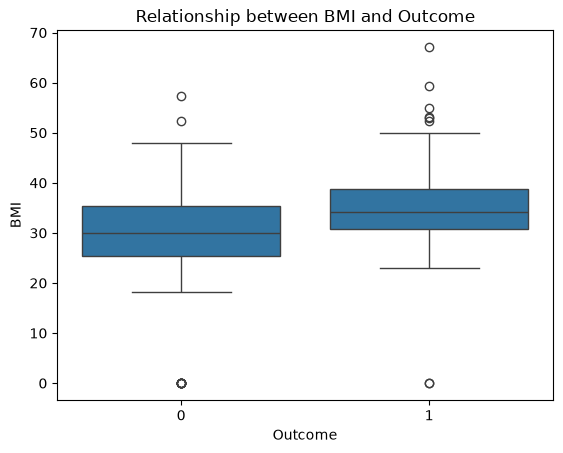

In [27]:
# Let's look at the relationship between BMI and Outcome
sns.boxplot(x=df.Outcome, y=df.BMI)
plt.title('Relationship between BMI and Outcome');

Patients with diabetes (Outcome 1) tend to have a higher BMI of approximately 35 than those without diabetes (Outcome 0) with approximately 30. There are outliers of high BMI which might suggest abnormal BMI. The 0 values are physiologically implausible and will be addressed as missing values.
The difference in BMI distributions suggests that BMI may be associated with diabetes status.

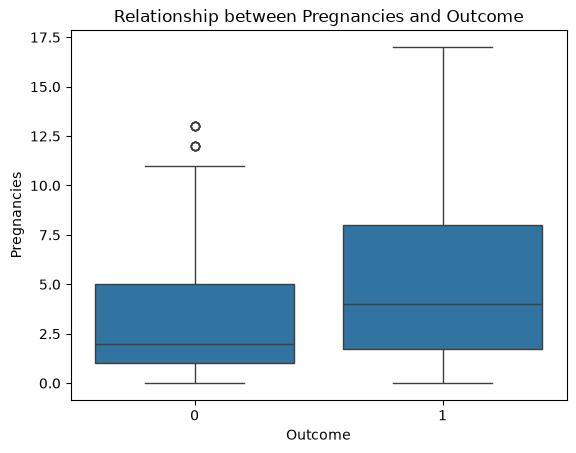

In [28]:
# Let's look at the relationship between Pregnancies and Outcome
sns.boxplot(x=df.Outcome, y=df.Pregnancies)
plt.title('Relationship between Pregnancies and Outcome');

The women with more pregnancies tend to have diabetic status (Outcome 1) with an approximate median of 4 pregnancies. 50% of women with no diabetes (Outcome 0) have pregnancies between approximately 1 and 5 pregnancies, with a median of approximately 2 pregnancies. 50% of women with diabetes have pregnancies between approximately 1 and 8 pregnancies. The diabetic distribution has a higher maximum boundary of approximately 17 pregnancies when compared to that of the non-diabetic distribution of 11 pregnancies.  

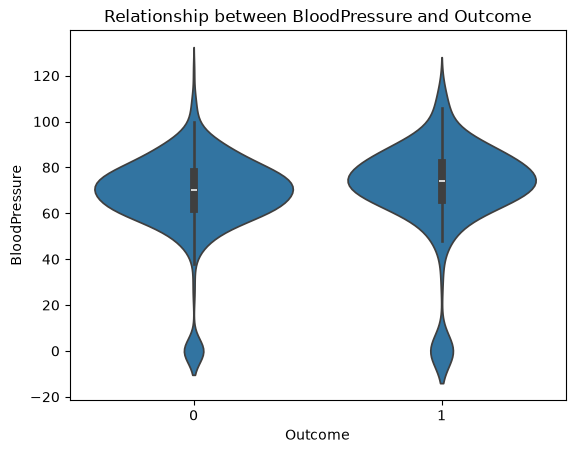

In [29]:
# Let's look at the relationship between BloodPressure and Outcome
sns.violinplot(data=df, x="Outcome", y="BloodPressure")
plt.title('Relationship between BloodPressure and Outcome');

The two distributions are very similar and overlapping. Outcome 0 has an approximate median of 70 while Outcome 1 has an approximate median of 73. This suggests that blood pressure may have a realtively weak association with diabetes status.

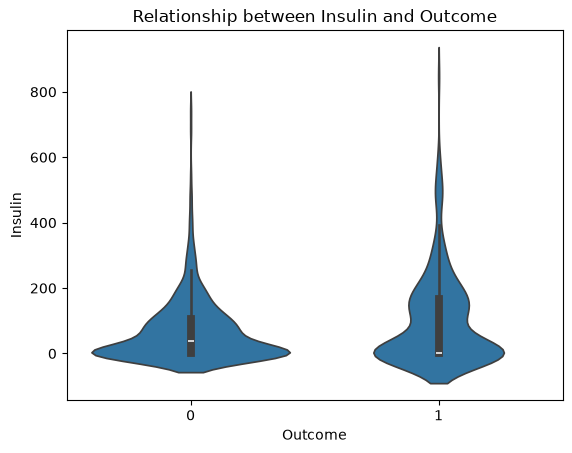

In [30]:
# Let's look at the relationship between Insulin and Outcome
sns.violinplot(data=df, x="Outcome", y="Insulin")
plt.title('Relationship between Insulin and Outcome');

The plot shows that insulin levels are highly right-skewed in both outcome groups, with most observations concentrated at the lower values and a long tail extending to very high insulin levels. A large concentration of observations occurs at an insulin value of 0, which is physiologically implausible and should be treated as a potential missing value during data cleaning. 

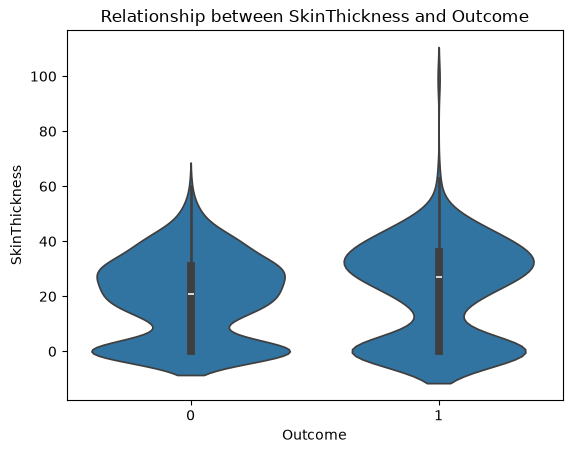

In [31]:
# Let's look at the relationship between SkinThickness and Outcome
sns.violinplot(x=df.Outcome, y=df.SkinThickness)
plt.title('Relationship between SkinThickness and Outcome');

The diabetic group has a slightly higher median with approximately 23 compared to the median of non-diabetic group of approximately 20. There is a substantial overlap. This means that SkinThickness does not appear to strongly distinguish the two outcome groups.

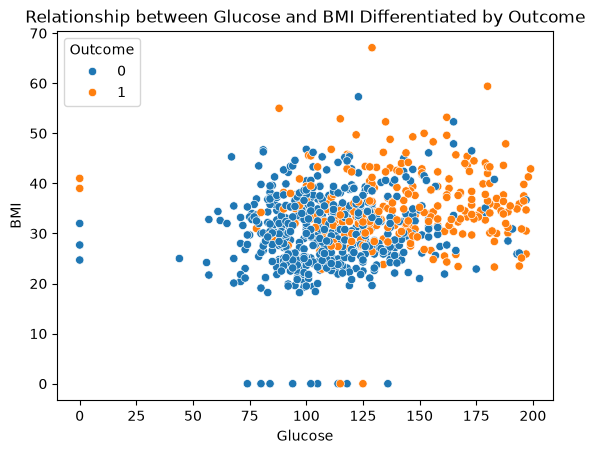

In [32]:
# Let's look at the relationship between Glucose, BMI and outcome
sns.scatterplot(
    data=df,
    x='Glucose',
    y='BMI',
    hue='Outcome'
)
plt.title('Relationship between Glucose and BMI Differentiated by Outcome');

Patients with diabetes are generally more concentrated at higher glucose levels compared with patients without diabetes. Several observations have a glucose value of 0, which is physiologically implausible and should be treated as missing during data cleaning.

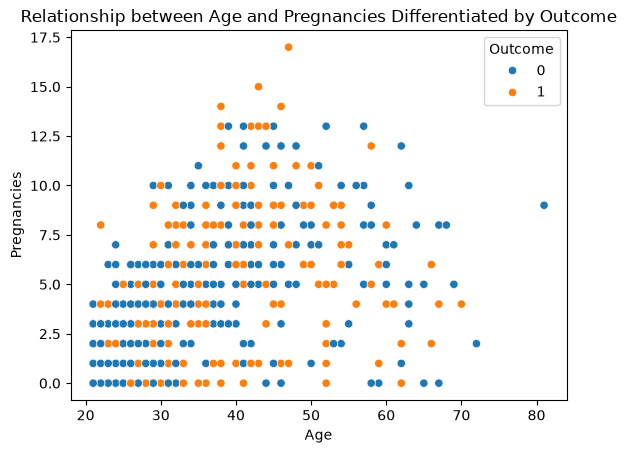

In [35]:
# Let's look at the relationship between Age, Pregnancies and outcome
sns.scatterplot(
    data=df,
    x='Age',
    y='Pregnancies',
    hue='Outcome'
)
plt.title('Relationship between Age and Pregnancies Differentiated by Outcome');

There appears to be a weak to moderate positive realtionship between age and pregnancies. Most observations are concentrated at lower pregnancies counts. There is a considerable overlap between Outcome 1 and Outcome 0, therefore age and preganancies alone do not appear to clearly distinguish individuals with Outcome o from those with Outcome 2.

## Dataset Limitations
1. It is not suitable as a clinical diagnostic system
2. It is a relatively small dataset
3. It is based on a specific population and gender

## Key EDA Findings

1. Class distribution: Outcome 0 accounts for approximately 65% of observations, while Outcome 1 accounts for approximately 35%.

2. Missing/invalid values: Several predictors contain zero values that may represent missing measurements, particularly Insulin (48.7%) and SkinThickness (29.6%).

3. Glucose: Outcome 1 observations generally have higher glucose values than Outcome 0 observations.

4. BMI: Outcome 1 observations tend to have higher BMI values, although substantial overlap exists.

5. Age: Age is positively skewed, with substantially more younger observations.

6. Insulin: Insulin has substantial dispersion and extreme values and will require further investigation during preprocessing.

7. Insulin: 51% of the Diabetic group (Outcome 1) has zero values while 47% of the Non-diabetic (Outcome 0) group has zero values

These findings will guide the data-cleaning and preprocessing decisions in the next stage.